## CSC14004 - Khai thác dữ liệu & Ứng dụng - CQ2023/21

### ĐỒ ÁN 2 - KHAI THÁC TẬP PHỔ BIẾN

#### Nhóm: 10

##### Chương 4: Thực nghiệm và đánh giá

**Khởi tạo môi trường**

In [1]:
using Pkg;
Pkg.instantiate()

**Load thuật toán và import các thư viện cần thiết**

In [2]:
include("../src/algorithm/fpclose.jl")
include("../src/algorithm/io.jl")
Pkg.add(["CSV", "DataFrames", "Plots", "StatsPlots"])

    Updating registry at `C:\Users\Admin\.julia\registries\General.toml`
   Resolving package versions...
     Project No packages added to or removed from `D:\Khai thác dữ liệu & Ứng dụng\Đồ án 2\notebooks\Project.toml`
    Manifest No packages added to or removed from `D:\Khai thác dữ liệu & Ứng dụng\Đồ án 2\notebooks\Manifest.toml`


**a. Kiểm tra tính đúng đắn (Correctness)**

In [3]:
using Unicode

# Định nghĩa kiểu dữ liệu chứa thông tin cấu hình một dataset
struct CompareResult
    n_my :: Int
    n_spmf :: Int
    exact_match :: Int
    wrong_support :: Vector{Tuple{String, Int, Int}}
    only_in_mine :: Vector{Tuple{String, Int}}
    only_in_spmf :: Vector{Tuple{String, Int}}
end

# Định nghĩa kiểu dữ liệu chứa toàn bộ kết quả so sánh giữa cài đặt của nhóm và SPMF.
struct DatasetConfig
    name :: String
    file :: String
    minsup_pct :: Float64
end

In [4]:
# Tính toán các chỉ số để so sánh bao gồm: Match Rate, Recall, Precision
function metrics(r::CompareResult)
    denom_spmf = max(r.n_spmf, 1)
    denom_my = max(r.n_my, 1)
    match_rate = round(r.exact_match / denom_spmf * 100, digits = 2)
    recall = round((r.exact_match + length(r.wrong_support)) / denom_spmf * 100, digits = 2)
    precision = round(r.exact_match / denom_my * 100, digits = 2)
    return (match_rate = match_rate, recall = recall, precision = precision)
end

metrics (generic function with 1 method)

In [5]:
# Chuẩn hóa itemset thành key dạng "1 2 3" (đã sort) để so sánh nhất quán
normalize_key(items) = join(sort(collect(items)), " ")

# Đọc file output của SPMF
function load_spmf(path::String) :: Dict{String, Int}
    result = Dict{String, Int}()
    open(path, "r") do f
        for line in eachline(f)
            m = match(r"^(.*?)\s*#SUP:\s*(\d+)\s*$", strip(line))
            m === nothing && continue
            result[normalize_key(split(m[1]))] = parse(Int, m[2])
        end
    end
    return result
end

# Chạy thuật toán của nhóm
function run_my_algorithm(filepath::String, minsup_pct::Float64) :: Dict{String, Int}
    transactions = load_transactions(filepath)
    minsup_abs = minsup_to_absolute(transactions, minsup_pct)
    results = run_fpclose(transactions, minsup_abs)
    return Dict(normalize_key(its) => sup for (its, sup) in results)
end

run_my_algorithm (generic function with 1 method)

In [6]:
# So sánh và phân loại từng itemset vào 4 nhóm: khớp hoàn toàn, sai support, chỉ có trong cài đặt (thừa), chỉ có trong SPMF (bỏ sót).
function compare(my_dict::Dict{String,Int}, spmf_dict::Dict{String,Int}) :: CompareResult
    exact = 0
    wrong_sup = Tuple{String, Int, Int}[]
    only_mine = Tuple{String, Int}[]
    only_spmf = Tuple{String, Int}[]

    for k in union(keys(my_dict), keys(spmf_dict))
        in_my = haskey(my_dict,   k)
        in_spmf = haskey(spmf_dict, k)

        if in_my && in_spmf
            my_dict[k] == spmf_dict[k] ? (exact += 1) :
                push!(wrong_sup, (k, my_dict[k], spmf_dict[k]))
        elseif in_my
            push!(only_mine, (k, my_dict[k]))
        else
            push!(only_spmf, (k, spmf_dict[k]))
        end
    end

    return CompareResult(length(my_dict), length(spmf_dict),exact, wrong_sup, only_mine, only_spmf)
end

compare (generic function with 1 method)

In [7]:
# Vẽ table biểu thị kết quả
function print_table(header, rows)
    str_width(s) = sum(Unicode.textwidth(c) for c in string(s); init = 0)
    rpad_u(s, w) = string(s) * " " ^ max(0, w - str_width(s))
    n = length(header)
    widths = [str_width(string(h)) for h in header]
    for row in rows
        for (j, cell) in enumerate(row)
            widths[j] = max(widths[j], str_width(string(cell)))
        end
    end
    top = "┌" * join(["─"^(w + 2) for w in widths], "┬") * "┐"
    mid = "├" * join(["─"^(w + 2) for w in widths], "┼") * "┤"
    bot = "└" * join(["─"^(w + 2) for w in widths], "┴") * "┘"
    println(top)
    println("│ " * join([rpad_u(header[j], widths[j]) for j in 1:n], " │ ") * " │")
    println(mid)
    for row in rows
        println("│ " * join([rpad_u(row[j], widths[j]) for j in 1:n], " │ ") * " │")
    end
    println(bot)
end

print_table (generic function with 1 method)

In [8]:
# In tối đa max_n ví dụ cho mỗi nhóm (thừa / bỏ sót / support sai)
function print_examples(title, entries, header, max_n)
    isempty(entries) && return
    shown = entries[1:min(max_n, end)]
    println("\n$title (tối đa $max_n)")
    print_table(header, [[i, t...] for (i, t) in enumerate(shown)])
end

# In báo cáo đầy đủ cho mỗi dataset
function print_report(ds::DatasetConfig, r::CompareResult; max_examples::Int=10)
    m = metrics(r)

    println("\n" * "="^60)
    println("  DATASET: $(ds.name)  (minsup = $(ds.minsup_pct * 100)%)")
    println("="^60)

    println("\nTỔNG QUAN")
    print_table(
        ["Nguồn", "Số itemsets"], [["Cài đặt", r.n_my],
        ["SPMF", r.n_spmf], ["Chênh lệch", abs(r.n_my - r.n_spmf)]]
    )
    println("\nPHÂN LOẠI KẾT QUẢ")
    print_table(
        ["Loại", "Số lượng", "Trạng thái"],
        [
            ["Khớp hoàn toàn", r.exact_match, "OK"],
            ["Itemset đúng, sup sai", length(r.wrong_support), "WARN"],
            ["Thừa (chỉ cài đặt)", length(r.only_in_mine), "ERR"],
            ["Bỏ sót (chỉ SPMF)", length(r.only_in_spmf), "ERR"],
        ]
    )
    println("\nCHỈ SỐ ĐÁNH GIÁ")
    print_table(
        ["Chỉ số", "Giá trị", "Ý nghĩa"],
        [
            ["Tỉ lệ khớp hoàn toàn", "$(m.match_rate)%", "exact_match / n_spmf"],
            ["Recall", "$(m.recall)%", "Tìm đủ itemset SPMF"],
            ["Precision", "$(m.precision)%",  "Không sinh thừa"],
        ]
    )
    print_examples("SUPPORT SAI", r.wrong_support, ["STT","Tập phổ biến","Cài đặt","SPMF"], max_examples)
    print_examples("BỎ SÓT", r.only_in_spmf, ["STT","Tập phổ biến","Support"], max_examples)
    print_examples("THỪA", r.only_in_mine, ["STT","Tập phổ biến","Support"], max_examples)
end

print_report (generic function with 1 method)

In [9]:
# Pipeline hoàn chỉnh cho từng dataset: load cả hai nguồn → so sánh → trả kết quả
function compare_dataset(ds::DatasetConfig, data_dir::String, spmf_dir::String) :: CompareResult
    my_dict = run_my_algorithm(joinpath(data_dir, ds.file), ds.minsup_pct)
    spmf_dict = load_spmf(joinpath(spmf_dir, splitext(ds.file)[1] * "_spmf.txt"))
    return compare(my_dict, spmf_dict)
end

# Chạy toàn bộ các dataset yêu cầu và in báo cáo cuối
function run_all_comparisons(
    datasets :: Vector{DatasetConfig};
    data_dir :: String = "../data/benchmark",
    spmf_dir :: String = "../data/benchmark",
)
    summary = []
    for ds in datasets
        r = compare_dataset(ds, data_dir, spmf_dir)
        print_report(ds, r)
        m = metrics(r)
        push!(summary, [ds.name, r.n_my, r.n_spmf, r.exact_match, "$(m.precision)%", "$(m.recall)%"])
    end
    
    println("\n" * "="^60)
    println("  TỔNG HỢP TẤT CẢ DATASET")
    println("="^60)
    print_table(["Dataset","Cài đặt","SPMF","Khớp","Precision","Recall"], summary)
end

run_all_comparisons (generic function with 1 method)

In [10]:
datasets = [
    DatasetConfig("Chess", "chess.txt", 0.60), DatasetConfig("Mushrooms", "mushrooms.txt", 0.20),
    DatasetConfig("Retail", "retail.txt", 0.001), DatasetConfig("Accidents", "accidents.txt", 0.4),
    DatasetConfig("T10I4D100K", "T10I4D100K.txt", 0.001)
]
run_all_comparisons(datasets)


  DATASET: Chess  (minsup = 60.0%)

TỔNG QUAN
┌────────────┬─────────────┐
│ Nguồn      │ Số itemsets │
├────────────┼─────────────┤
│ Cài đặt    │ 106363      │
│ SPMF       │ 98392       │
│ Chênh lệch │ 7971        │
└────────────┴─────────────┘

PHÂN LOẠI KẾT QUẢ
┌───────────────────────┬──────────┬────────────┐
│ Loại                  │ Số lượng │ Trạng thái │
├───────────────────────┼──────────┼────────────┤
│ Khớp hoàn toàn        │ 98392    │ OK         │
│ Itemset đúng, sup sai │ 0        │ WARN       │
│ Thừa (chỉ cài đặt)    │ 7971     │ ERR        │
│ Bỏ sót (chỉ SPMF)     │ 0        │ ERR        │
└───────────────────────┴──────────┴────────────┘

CHỈ SỐ ĐÁNH GIÁ
┌──────────────────────┬─────────┬──────────────────────┐
│ Chỉ số               │ Giá trị │ Ý nghĩa              │
├──────────────────────┼─────────┼──────────────────────┤
│ Tỉ lệ khớp hoàn toàn │ 100.0%  │ exact_match / n_spmf │
│ Recall               │ 100.0%  │ Tìm đủ itemset SPMF  │
│ Precision            │

**Nhận xét:**

- Recall đạt 100% trên toàn bộ 5 dataset — thuật toán không bỏ sót bất kỳ itemset đóng nào. Vấn đề duy nhất còn lại là sinh thừa itemset ở `Chess` và `Mushrooms`.

**Điểm mạnh & Điểm yếu**

**Điểm mạnh:**

- Recall 100% toàn bộ cho thấy thuật toán không còn bỏ sót itemset đóng nào.
- Support tính hoàn toàn chính xác, `wrong_support` = 0 trên tất cả dataset cho thấy nền tảng FP-Tree được xây dựng ổn định.
- Đạt hiệu suất cao trên 3/5 dataset (`Retail`, `Accidents`, `T10I4D100K`) khi các thông số Precision và Recall đều chạm 100%, chứng minh thuật toán đúng về mặt logic cốt lõi.
- Có hiệu quả tốt trên dataset thưa (`Retail` và `T10I4D100K`).

**Điểm yếu:**

| Dataset   | Vấn đề                  | Biểu hiện        | Mức độ     |
|-----------|-------------------------|------------------|------------|
| Chess     | Sinh thừa 7.971 itemset | Precision 92,51% | Trung bình |
| Mushrooms | Sinh thừa 222 itemset   | Precision 84,04% | Trung bình |

**Nguyên nhân:**
`Chess` và `Mushrooms` đều là dataset dày (dense) -> transaction có nhiều item, tạo ra nhiều itemset frequent với support gần nhau, khiến điều kiện đóng khó kiểm tra chính xác hơn.

**Đề xuất tối ưu hóa:**

1. Tăng cường `closed_checking` cho dataset dày

    - Vì lỗi chỉ xuất hiện ở dataset dày (Chess, Mushrooms), nguyên nhân nhiều khả năng là CFI-Tree chưa bao phủ hết các superset có cùng support khi không gian itemset rộng -> Cân nhắc kiểm tra lại hàm insert_cfi! và closed_checking.

2. Điều chỉnh `minsup` cho Chess và Mushrooms

    - Vì lỗi thừa đa phần tập trung ở minsup cao (Chess 60%, Mushrooms 20%) -> Ta có thể thử tăng nhẹ minsup để giảm không gian tìm kiếm và kiểm chứng xem lỗi có giảm theo không, từ đó giúp khoanh vùng nguyên nhân.

---

**Note:** Ở các thực nghiệm tiếp theo, nhóm sẽ chạy thuật toán FPClose MỘT LẦN cho mỗi (dataset, minsup), sau đó thu thập đồng thời thời gian, peak memory, số itemset sinh ra và lưu vào CSV để có thể tái sử dụng và giảm thời gian chờ.

In [11]:
# Khai báo cấu hình dùng chung cho notebook. 
const DATA_DIR = "../data/benchmark"
const BENCHMARK_CONFIGS = [
    (name = "Chess", file = "chess.txt", minsups = [0.90, 0.80, 0.70, 0.60, 0.50]),
    (name = "Mushrooms", file = "mushrooms.txt", minsups = [0.40, 0.30, 0.20, 0.1, 0.05]),
    (name = "Retail", file = "retail.txt", minsups = [0.10, 0.05, 0.02, 0.01, 0.005]),
    (name = "Accidents", file = "accidents.txt", minsups = [0.70, 0.60, 0.50, 0.40, 0.3]),
    (name = "T10I4D100K", file = "T10I4D100K.txt", minsups = [0.10, 0.05, 0.02, 0.01, 0.005])
]
const GROUP_CSV = "../data/benchmark/group_benchmark.csv"
const SPMF_CSV = "../data/benchmark/spmf_benchmark.csv"

"../data/benchmark/spmf_benchmark.csv"

In [12]:
using Printf, CSV, DataFrames

function run_group_benchmark(;
    configs = BENCHMARK_CONFIGS,
    data_dir = DATA_DIR,
    output_csv = GROUP_CSV,
)
    records = []

    for config in configs
        input_path = joinpath(data_dir, config.file)
        transactions = load_transactions(input_path)
        println("\nDataset: $(config.name)")
        println("─"^50)

        for minsup_pct in config.minsups
            minsup_abs = minsup_to_absolute(transactions, minsup_pct)

            GC.gc()   # dọn heap trước khi đo
            mem_before = Base.gc_live_bytes()
            t_start    = time_ns()
            results = run_fpclose(transactions, minsup_abs)
            elapsed_ms = (time_ns() - t_start) / 1_000_000
            peak_mb    = (Base.gc_live_bytes() - mem_before) / 1024 / 1024

            @printf("minsup = %6.2f%% → %7d itemsets | %9.2f ms | %8.2f MB\n",
                minsup_pct * 100, length(results), elapsed_ms, peak_mb)

            push!(records, (dataset = config.name, minsup = minsup_pct * 100,
                            elapsed_ms = round(elapsed_ms, digits = 2), peak_mb = round(peak_mb, digits = 2),
                            n_itemsets = length(results),))
        end
    end

    df = DataFrame(records)
    CSV.write(output_csv, df)
    return df
end

run_group_benchmark (generic function with 1 method)

In [13]:
group_df = run_group_benchmark();


Dataset: Chess
──────────────────────────────────────────────────
minsup =  90.00% →     499 itemsets |     26.00 ms |     6.03 MB
minsup =  80.00% →    5186 itemsets |     88.74 ms |    38.14 MB
minsup =  70.00% →   25134 itemsets |    883.97 ms |   111.24 MB
minsup =  60.00% →  106363 itemsets |  29483.61 ms |   119.69 MB
minsup =  50.00% →  411536 itemsets | 2035385.22 ms |   246.28 MB

Dataset: Mushrooms
──────────────────────────────────────────────────
minsup =  40.00% →     136 itemsets |     65.15 ms |    11.21 MB
minsup =  30.00% →     476 itemsets |     94.47 ms |    16.50 MB
minsup =  20.00% →    1391 itemsets |    166.61 ms |    36.28 MB
minsup =  10.00% →    6045 itemsets |    460.79 ms |   144.52 MB
minsup =   5.00% →   16586 itemsets |   3840.41 ms |    94.85 MB

Dataset: Retail
──────────────────────────────────────────────────
minsup =  10.00% →       9 itemsets |     85.64 ms |    16.66 MB
minsup =   5.00% →      16 itemsets |     77.51 ms |    17.04 MB
minsup =   2.

---

**b. Thời gian chạy theo từng mốc minsup**

In [14]:
using Plots

# Hàm vẽ biểu đồ
function time_plot(;
    configs = BENCHMARK_CONFIGS,
    spmf_csv = SPMF_CSV,
    group_csv = GROUP_CSV,
)

    # Đọc kết quả benchmark SPMF từ CSV
    df_spmf = CSV.read(spmf_csv, DataFrame)

    # Đọc kết quả benchmark của nhóm từ CSV
    df_group = CSV.read(group_csv, DataFrame)

    # Tính số hàng subplot để chia 2 cột
    ncols = 2
    nrows = ceil(Int, length(configs) / ncols)
    plots = []

    for config in configs
        # Lọc và sắp xếp kết quả theo minsup giảm dần để khớp trục X
        spmf_rows = sort(filter(r -> r.dataset == config.name, df_spmf), :minsup, rev = true)
        group_rows = sort(filter(r -> r.dataset == config.name, df_group), :minsup, rev = true)

        # Khởi tạo subplot
        p = plot(title = config.name, xlabel = "Minsup (%)", ylabel = "Thời gian (ms)",
                    legend = :topleft, xflip = true, linewidth = 2, marker = :circle, markersize = 5,
                    grid = true,)

        # Vẽ đường SPMF
        plot!(p, spmf_rows.minsup, spmf_rows.elapsed_ms, label = "SPMF", color = :steelblue, linestyle = :solid)
        
        # Vẽ đường cài đặt nhóm
        plot!(p, group_rows.minsup, group_rows.elapsed_ms, label = "Cài đặt nhóm", color = :crimson, linestyle = :dash)
        push!(plots, p)
    end

    # Ghép tất cả subplot thành một figure duy nhất
    fig = plot(plots..., layout = (nrows, ncols), size = (900, 300 * nrows),
                plot_title = "So sánh thời gian chạy: Cài đặt nhóm vs SPMF", margin = 5Plots.mm,)
    return fig
end

time_plot (generic function with 1 method)

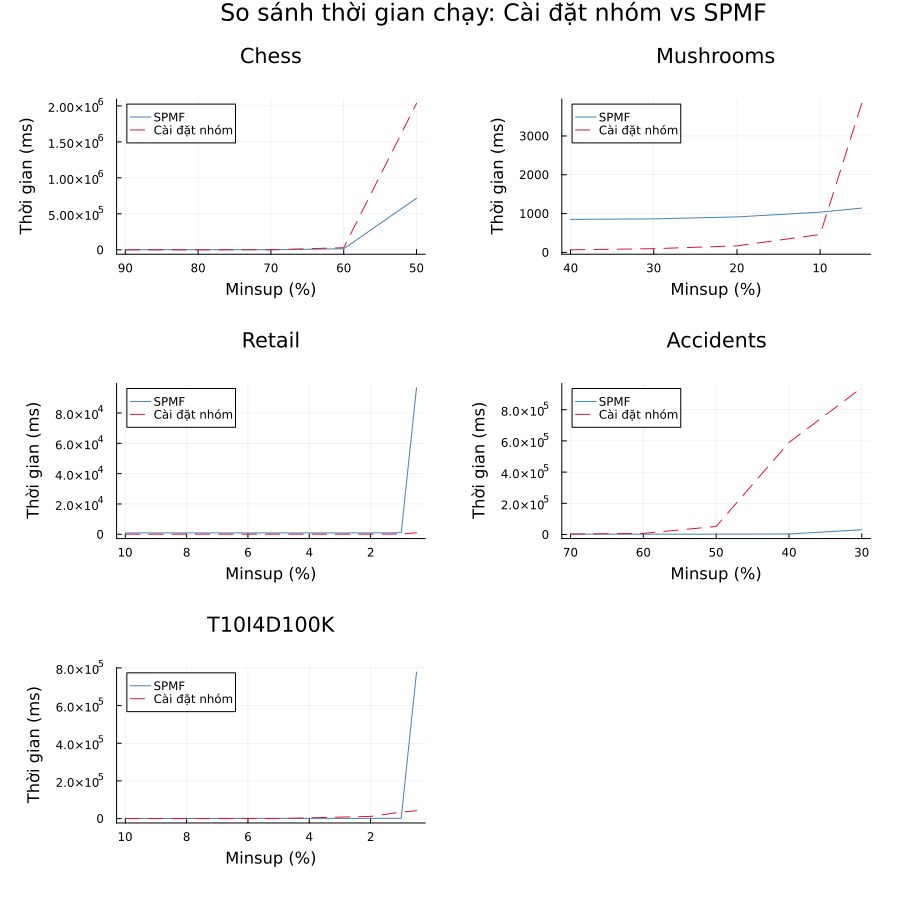

In [15]:
time_plot()

**Nhận xét:**
- Trên các dataset thưa (sparse) như `Retail` và `T10I4D100K`, hai đường (nhóm và SPMF) chạy gần nhau và có độ dốc thấp. Nó cho thấy cài đặt của nhóm đạt hiệu suất tương đương SPMF.

    -> Nguyên nhân: transaction ngắn, số itemset frequent ít nên chi phí xây và duyệt conditional database thấp.

- Trên các dataset dày (dense) như `Chess`, `Mushrooms`, và `Accidents`, đường cài đặt nhóm cao hơn đường SPMF ở minsup thấp. Chess ở minsup 50% mất ~34 phút, Accidents ở minsup 30% mất ~15 phút -> đây là mức chênh lệch rất lớn so với một cài đặt tham chiếu được tối ưu.

- Xu hướng chung: thời gian tăng mạnh khi minsup giảm, đặc biệt rõ ở dataset dày, mỗi bước giảm minsup có thể nhân thời gian lên hàng chục lần do bùng nổ tổ hợp. `T10I4D100K` còn cho thấy bước nhảy đột biến tại minsup 2% (từ 60ms lên 11.530ms). Điều đó cho thấy khả năng tồn tại một ngưỡng minsup tới hạn mà dưới đó cấu trúc FP-Tree bị thay đổi bản chất.


**Điểm mạnh:**
- Thời gian tăng tỷ lệ hợp lý với số itemset ở mức minsup cao: `Chess` từ 90% → 70%, số itemset tăng từ 499 lên 25.134 (~50x) và thời gian tăng từ 26ms lên 884ms (~34x). 
    
    -> Tỷ lệ này gần tuyến tính, chứng tỏ chi phí xử lý mỗi itemset khá ổn định khi FP-Tree còn nhỏ.

- Dataset thưa duy trì thời gian thấp dù itemset tăng: `Retail` tăng từ 9 lên 580 itemset (~64x) nhưng thời gian chỉ tăng từ 85ms lên 1.005ms (~12x).

    -> Số itemset tăng nhiều hơn so với thời gian, nghĩa là thuật toán đang tận dụng tốt cấu trúc FP-Tree thưa để xử lý nhiều itemset với chi phí biên thấp.

**Điểm yếu:**
- Thời gian tăng nhanh hơn số itemset trên dataset dày ở minsup thấp: `Chess` từ 70%→50%, số itemset tăng ~16x (25.134 → 411.536) nhưng thời gian tăng ~2.300x (884ms → 2.035.385ms).

    -> Đây là dấu hiệu rõ ràng của việc thuật toán không chỉ phải xử lý nhiều itemset hơn mà còn phải xây dựng và duyệt nhiều conditional FP-Tree lớn hơn, kiểm tra đóng trên CFI-Tree ngày càng phình to.

**Đề xuất tối ưu hóa:**
- Tách chiến lược xử lý theo loại dataset: Dựa trên tỷ lệ (số itemset) / (thời gian) đo được, có thể phát hiện tự động dataset đang ở chế độ dày hay thưa, rồi chọn chiến lược phù hợp
    - **array-based FP-Tree** (cache-friendly, ít GC hơn) cho dataset dày.
    - **linked-list FP-Tree** thông thường cho dataset thưa.

    -> Điều này tránh overhead của array khi dataset thưa (FP-Tree nhỏ, không cần tối ưu bộ nhớ) trong khi vẫn tận dụng được tốc độ khi dataset dày.

---

**c. Số lượng frequent itemset theo minsup**

In [16]:
function plot_itemset_counts(; group_csv = GROUP_CSV)
    df = CSV.read(group_csv, DataFrame)
    ncols = 2
    nrows = ceil(Int, length(BENCHMARK_CONFIGS) / ncols)
    plots = []

    for config in BENCHMARK_CONFIGS
        rows = sort(filter(r -> r.dataset == config.name, df), :minsup, rev=true)
        p = plot(rows.minsup, rows.n_itemsets, title = config.name, xlabel = "Minsup (%)",
                    ylabel = "Số itemset", legend = false, xflip = true, linewidth = 2, marker = :circle,
                    markersize = 5, color = :crimson, grid = true,)
        push!(plots, p)
    end
    
    return plot(plots..., layout = (nrows, ncols), size = (900, 300 * nrows),
                plot_title = "Số lượng frequent itemset theo minsup", margin = 5Plots.mm,)
end

plot_itemset_counts (generic function with 1 method)

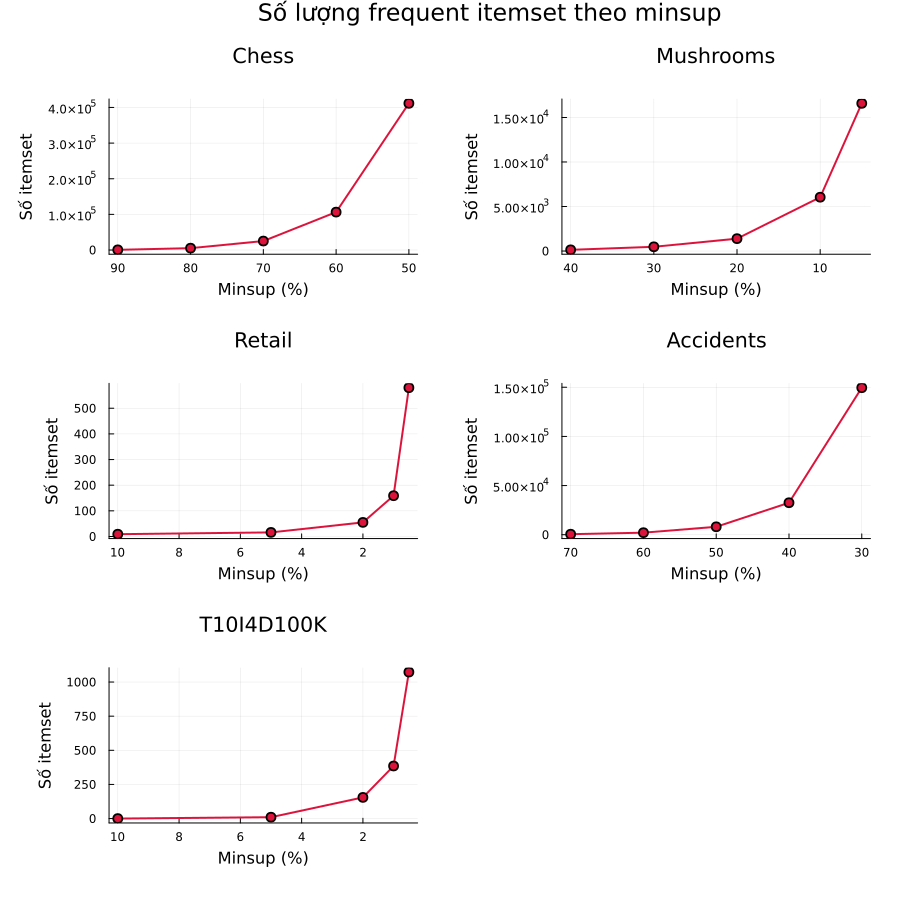

In [17]:
plot_itemset_counts()

**Nhận xét:**
- Cả 5 dataset đều thể hiện xu hướng chung: số lượng itemset tăng khi minsup giảm, nhưng tốc độ tăng khác nhau rõ rệt giữa dataset dày và thưa.

- `Chess` và `Accidents` có mức tăng dốc ở minsup thấp: `Chess` đạt ~4×10⁵ itemset ở minsup 50%, `Accidents` đạt ~1.5×10⁵ itemset ở minsup 30%. Đường cong gần như nằm ngang ở minsup cao rồi bẻ gập đột ngột -> cho thấy sự bùng nổ tổ hợp trên dataset dày.

- `Mushrooms` có biểu hiện tương tự nhưng nhẹ hơn, đạt ~1.6×10⁴ itemset ở minsup 5%.

- `Retail` và `T10I4D100K` tăng chậm nhưng cũng bắt đầu bẻ cong mạnh ở các minsup thấp (0.5% và 1% tương ứng). `T10I4D100K` tăng ~10x chỉ trong bước minsup cuối (2%→0.5%).

**Điểm mạnh:**
- Số itemset sinh ra phản ánh đúng cấu trúc dữ liệu: dataset dày (`Chess`, `Accidents`, `Mushrooms`) cho số itemset lớn hơn nhiều so với dataset thưa ở cùng mức minsup tương đối.

- Hình dạng đường cong nhất quán vì không có bước nhảy bất thường hay điểm ngoại lệ cục bộ cho thấy thuật toán hoạt động ổn định và không có lỗi logic trong việc liệt kê itemset.

**Điểm yếu:**

- Số itemset của nhóm bị thổi phồng trên `Chess` và `Mushrooms`, mặt khác, precision chưa đạt 100% (`Chess` = 92.51%, `Mushrooms` = 84.04%) cho thấy một phần trong itemset của `Chess` và `Mushrooms` là itemset thừa không đóng. Điều này có nghĩa đường cong thực tế nên nằm thấp hơn một chút so với đường cong SPMF tham chiếu.

- Tốc độ bùng nổ quá cao ở minsup thấp trên dataset dày: Với `Chess` ở mức minsup 50%, gần 411.000 itemset được sinh ra, lưu trữ và kiểm tra đóng. Đây vừa là vấn đề thời gian, vừa là vấn đề bộ nhớ (peak memory đạt 246MB).

**Đề xuất tối ưu hóa:**

1. Đặt ngưỡng cảnh báo minsup tự động

    Dựa trên số itemset ở các mốc minsup đã đo, có thể xây dựng một hàm ước lượng nhanh (chạy trên sample 10% dữ liệu) để dự báo số itemset tại minsup người dùng nhập. Nếu ước lượng vượt ngưỡng (ví dụ 100.000 itemset), cảnh báo người dùng hoặc tự động đề xuất tăng minsup để tránh chạy full trên các cấu hình không khả thi.

2. Áp dụng **levelwise pruning** kết hợp với **CFI-Tree**

    Thay vì sinh tất cả itemset rồi lọc sau, có thể tích hợp thêm bước kiểm tra **monotonicity** của closed itemset: nếu một itemset P đã biết là không đóng ở level k, thì tất cả subset của P cũng không cần kiểm tra lại khi xây conditional database. Kỹ thuật này có thể hiệu quả khi số itemset bùng nổ ở các dataset như `Chess` và `Accidents`, vì nó cắt bỏ sớm một lượng lớn nhánh tìm kiếm trước khi conditional FP-Tree được xây dựng.

---

**d. Mức sử dụng bộ nhớ**

In [18]:
using StatsPlots
function plot_memory(; spmf_csv = SPMF_CSV, group_csv = GROUP_CSV)
    df_spmf = CSV.read(spmf_csv, DataFrame)
    df_group = CSV.read(group_csv, DataFrame)

    # Lấy minsup trung bình cho từng dataset
    memory_rows = [
        (
            name = config.name,
            minsup = config.minsups[ceil(Int, length(config.minsups) / 2)] * 100
        )
        for config in BENCHMARK_CONFIGS
    ]

    spmf_mbs = [filter(r -> r.dataset == c.name && r.minsup == c.minsup, df_spmf)[1, :peak_mb] for c in memory_rows]
    group_mbs = [filter(r -> r.dataset == c.name && r.minsup == c.minsup, df_group)[1, :peak_mb] for c in memory_rows]
    labels = [
        "$(c.name)\n(minsup=$(round(c.minsup, digits=2))%)"
        for c in memory_rows
    ]
    
    groupedbar(labels, [group_mbs spmf_mbs], label = ["Cài đặt nhóm" "SPMF"], xlabel = "Dataset",
                ylabel = "Peak Memory (MB)", title = "So sánh memory usage", color = [:crimson :steelblue],
                bar_width = 0.6, legend = :topleft, grid = true, size = (700, 700),)
end

plot_memory (generic function with 1 method)

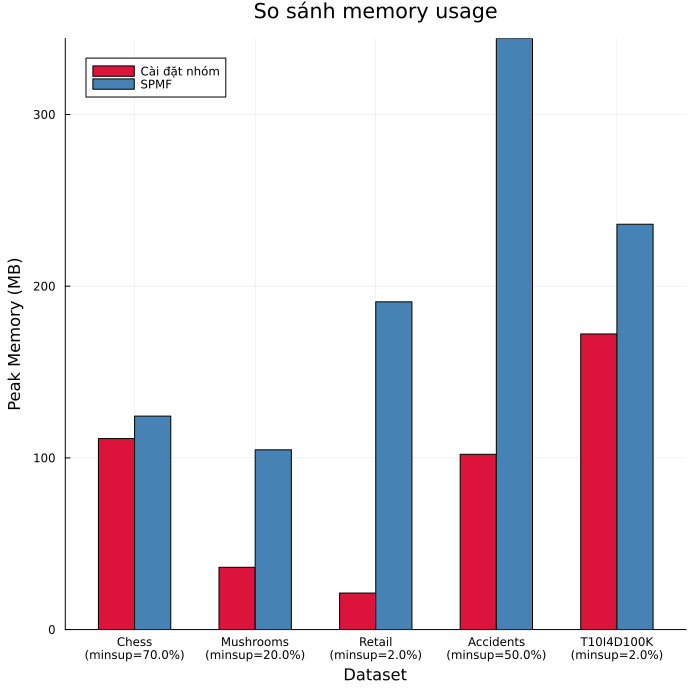

In [19]:
plot_memory()

**Nhận xét:**

- Cài đặt nhóm (đỏ) dùng ít bộ nhớ hơn SPMF (xanh) trên toàn bộ 5 dataset.

- Khoảng cách lớn nhất ở `Accidents` (minsup = 50%): nhóm dùng ~103MB trong khi SPMF dùng ~335MB -> tiết kiệm hơn 3x. `T10I4D100K` cũng cho khoảng cách đáng kể: ~172MB so với ~235MB của SPMF.

**Điểm mạnh:**

- Hiệu quả bộ nhớ vượt trội so với SPMF trên mọi dataset, đặc biệt trên `Accidents` và `T10I4D100K`. Nó cho thấy cấu trúc FP-Tree và CFI-Tree được GC thu dọn tốt hơn so với JVM heap của SPMF, hoặc cài đặt nhóm tái sử dụng bộ nhớ hiệu quả hơn trong quá trình xây conditional database.

- Bộ nhớ tăng có kiểm soát theo độ phức tạp của dataset: từ Retail (~21MB) đến Accidents (~103MB). Mức tăng này phản ánh đúng độ dày của dataset và không có outlier bất thường, cho thấy không có memory leak hay cấp phát thừa.

**Điểm yếu:**

- Nên đặt số liệu **memory** cạnh số liệu **thời gian**. `Accidents` dùng ít bộ nhớ hơn SPMF 3 lần nhưng lại chậm hơn rất nhiều. Nó cho thấy cài đặt của nhóm khả năng cao đang đánh đổi thời gian lấy bộ nhớ, nguyên nhân có thể do không cache lại các cấu trúc trung gian (conditional FP-Tree, projected database) mà tái tính lại nhiều lần, dẫn đến tiết kiệm RAM nhưng tốn CPU.

**Đề xuất tối ưu hóa**

- Dùng lại bộ nhớ conditional FP-Tree thay vì cấp phát mới mỗi lần
    
    Nếu thuật toán đang có hiện tượng cấp phát heap mới cho mỗi prefix thì ta có thể dùng một **object pool** hoặc **pre-allocated buffer** tái sử dụng cho các conditional FP-Tree nhỏ giúp giảm áp lực GC, giảm thời gian cấp phát, và đặc biệt có lợi trên `Chess` và `Accidents` nơi hàng nghìn conditional database được xây liên tiếp. Điều này cũng giúp peak memory đo được phản ánh được giá trị thực tế hơn vì GC ít phải can thiệp giữa chừng.

---

**e. Khả năng mở rộng (Scalability)**

Tập dữ liệu: Retail

In [20]:
# Hằng số cấu hình
const SCALE_FRACS    = [0.10, 0.25, 0.50, 0.75, 1.00]
const SCALE_OUT_CSV  = "../data/benchmark/retail_scalability.csv"

"../data/benchmark/retail_scalability.csv"

In [21]:
# Định nghĩa kiểu dữ liệu của kết quả đo
struct ScaleRecord
    fraction   :: Float64
    n_trans    :: Int
    n_itemsets :: Int
    elapsed_ms :: Float64
end

In [22]:
# Hàm tạo các tập con, chú ý không xáo trộn để đảm bảo tính tái lập và tính lồng nhau.
# 10% ⊂ 25% ⊂ 50% ⊂ 75% ⊂ 100%

function subset_transactions(transactions::Vector, frac::Float64)::Vector
    @assert 0.0 < frac <= 1.0 "frac phải nằm trong (0, 1]"
    n = ceil(Int, frac * length(transactions))
    return transactions[1:n]
end

subset_transactions (generic function with 1 method)

In [23]:
function measure_once(transactions::Vector, minsup_pct::Float64, frac::Float64)::ScaleRecord
    n_trans = length(transactions)
    minsup_abs = minsup_to_absolute(transactions, minsup_pct)
    start_time = time_ns()
    results = run_fpclose(transactions, minsup_abs)
    elapsed_ms = (time_ns() - start_time) / 1_000_000
    return ScaleRecord(frac * 100, n_trans, length(results),round(elapsed_ms, digits = 2),)
end

measure_once (generic function with 1 method)

In [24]:
# Hàm chuyển vector `ScaleRecord` thành DataFrame để lưu CSV -> vẽ đồ thị.
function records_to_df(records::Vector{ScaleRecord})::DataFrame
    return DataFrame(
        fraction   = [r.fraction for r in records],
        n_trans    = [r.n_trans for r in records],
        n_itemsets = [r.n_itemsets for r in records],
        elapsed_ms = [r.elapsed_ms for r in records],
    )
end

records_to_df (generic function with 1 method)

In [25]:
# hàm chính
function run_scalability(;
    filepath = "../data/benchmark/retail.txt",
    minsup_pct = 0.001,
    fractions  :: Vector  = SCALE_FRACS,
    output_csv :: String  = SCALE_OUT_CSV,
)::DataFrame

    all_tx = load_transactions(filepath)

    println("Dataset : Retail  ($(length(all_tx)) giao dịch)")
    println("Minsup : $(minsup_pct * 100)%")
    println("─"^65)
    @printf(" %-8s %-12s %-12s %-12s \n",
            "Tỉ lệ", "Giao dịch", "Itemsets", "Thời gian")
    println("─"^65)

    records = ScaleRecord[]

    for frac in fractions
        subset = subset_transactions(all_tx, frac)
        rec = measure_once(subset, minsup_pct, frac)
        push!(records, rec)

        @printf(" %5.0f%% %8d %8d %9.2f ms\n",
                rec.fraction, rec.n_trans,
                rec.n_itemsets, rec.elapsed_ms)
    end

    df = records_to_df(records)
    CSV.write(output_csv, df)
    println("─"^65)
    println("Đã lưu: $output_csv")
    return df
end

run_scalability (generic function with 1 method)

In [26]:
# vẽ biểu đồ
function plot_scalability(df::DataFrame; save_path::String = "")
    pcts = df.fraction
    fig = plot(df.fraction,df.elapsed_ms;seriestype = :line,
                title = "Khả năng mở rộng của FP-Close trên Retail",
                xlabel = "Kích thước tập dữ liệu (%)",
                ylabel = "Thời gian chạy (ms)",label = "FP-Close",
                color = :steelblue, linewidth = 3, marker = :circle,
                markersize = 7, legend = :topleft, grid = true, xticks = df.fraction,
                size = (700, 700))
                
    if !isempty(save_path)
        savefig(fig, save_path)
    end
    return fig
end

plot_scalability (generic function with 1 method)

Dataset : Retail  (88162 giao dịch)
Minsup : 0.1%
─────────────────────────────────────────────────────────────────
 Tỉ lệ    Giao dịch    Itemsets     Thời gian    
─────────────────────────────────────────────────────────────────
    10%     8817     9687    735.19 ms
    25%    22041     8746    803.43 ms
    50%    44081     8134   2480.73 ms
    75%    66122     7277   4430.92 ms
   100%    88162     7572   7839.47 ms
─────────────────────────────────────────────────────────────────
Đã lưu: ../data/benchmark/retail_scalability.csv


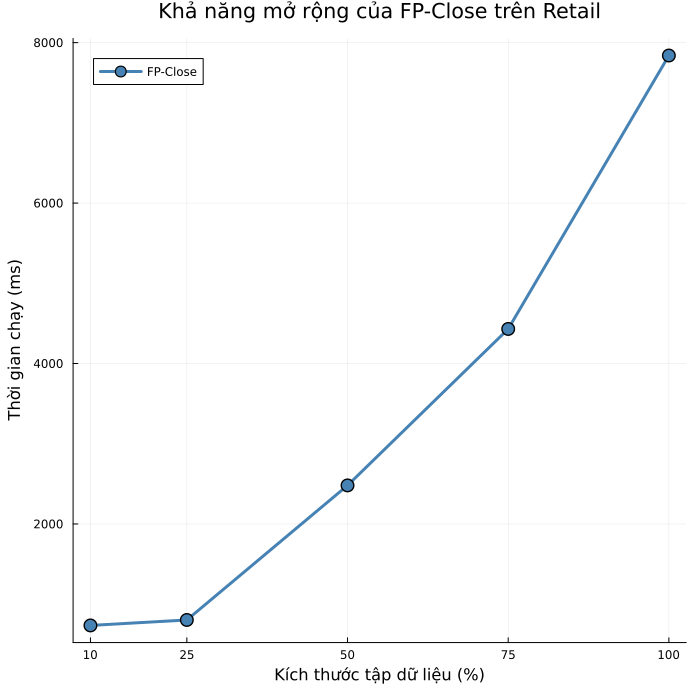

In [27]:
df_scale = run_scalability();
plot_scalability(df_scale)

**Nhận xét:**

- Đường cong không tuyến tính: từ 10% đến 25% gần như phẳng (735ms → 803ms, tăng chỉ ~9%), nhưng từ 25% đến 100% tăng dốc mạnh (~10x)
    
    -> Thuật toán có chi phí khởi động cố định (fixed overhead) khi xây FP-Tree ban đầu, sau đó chi phí tăng theo kích thước dữ liệu.

**Điểm mạnh:**

- Khả năng mở rộng chấp nhận được trên dataset thưa
    - Từ 10% lên 100% (tăng 10x dữ liệu), thời gian chỉ tăng ~10.7x (735ms→7.839ms). Tỷ lệ này gần tuyến tính tổng thể, chứng tỏ FPClose hoạt động tốt trên dữ liệu thưa khi scale up.

- Vùng 10% – 25% cực kỳ ổn định khi tăng 2.5x dữ liệu mà thời gian không thay đổi đáng kể, cho thấy FP-Tree ở quy mô nhỏ được xử lý hiệu quả và overhead cấu trúc dữ liệu được khấu hao tốt.

**Điểm yếu:**

- Đường cong tăng dốc ở nửa sau (50% → 100%)
    - Độ dốc rõ ràng lớn hơn nửa đầu, nếu ngoại suy lên 200% hoặc 500% dữ liệu, thời gian có thể sẽ tăng phi tuyến đáng lo ngại
    
    -> Thuật toán chưa thể hiện scalability thực sự tuyến tính.

- Thực nghiệm chỉ trên một dataset thưa với một minsup cố định (0.1%) nên chưa đủ để kết luận về scalability tổng quát. Trên dataset dày như `Chess` hay `Accidents`, đường cong khi tăng kích thước dữ liệu có thể sẽ dốc hơn nhiều do FP-Tree sâu hơn và conditional database lớn hơn theo cấp số nhân.

**Đề xuất tối ưu hóa:**

- Mở rộng thực nghiệm scalability sang dataset dày và nhiều mức minsup

    - Để đánh giá scalability toàn diện, cần lặp lại thực nghiệm trên Accidents hoặc Chess với các phần trăm tương tự (10% → 100%), đồng thời thử 3 mức minsup khác nhau cho mỗi dataset. Kết quả sẽ cho phép ta vẽ họ đường cong phân tầng theo loại dataset, từ đó xác định ngưỡng thuật toán bắt đầu mất kiểm soát.

---

**f. Ảnh hưởng của độ dài giao dịch trung bình lên thuật toán**

**Ý tưởng:**

Ta sẽ giữ cố định:

- Số giao dịch: 50.000
- Số item khác nhau: 1.000
- Minsup: 1%

Và chỉ thay đổi độ dài trung bình của giao dịch

Ví dụ:

| Dataset    | Số giao dịch | Số item        | Độ dài giao dịch |
|------------|--------------|----------------|------------------|
| D5         | 50000        | 1000           | 5                |
| D10        | 50000        | 1000           | 10               |
| D20        | 50000        | 1000           | 20               |
| D40        | 50000        | 1000           | 40               |
| D80        | 50000        | 1000           | 80               |

Sau đó đo:
- Runtime (ms)
- Peak memory (MB)
- Số closed frequent itemsets

**Giả thuyết:** Nếu FP-Close bị ảnh hưởng bởi transaction length thì thời gian sẽ tăng khi độ dài giao dịch tăng.

In [28]:
# Cấu hình cho thực nghiệm
const LENGTH_CONFIGS = [5, 10, 20, 40, 60]
const N_TRANSACTIONS = 50000
const N_ITEMS = 1000
const LENGTH_MINSUP = 0.01

0.01

In [29]:
# Tạo cơ sở dữ liệu
using Random

function generate_transaction(len::Int,n_items::Int)
    return string.(randperm(n_items)[1:len])
end

function generate_dataset(n_transactions::Int,n_items::Int, transaction_length::Int)
    return [
        generate_transaction(
            transaction_length,
            n_items
        )
        for _ in 1:n_transactions
    ]
end

generate_dataset (generic function with 1 method)

In [30]:
function run_length_experiment()
    records = NamedTuple[]
    for tx_length in LENGTH_CONFIGS
        println("\nTransaction length = ", tx_length)
        transactions = generate_dataset(N_TRANSACTIONS, N_ITEMS, tx_length)
        minsup_abs = minsup_to_absolute(transactions, LENGTH_MINSUP)

        GC.gc()
        mem_before = Base.gc_live_bytes()
        start_time = time_ns()
        results = run_fpclose(transactions, minsup_abs)
        elapsed_ms = (time_ns() - start_time) / 1_000_000
        memory_mb = (Base.gc_live_bytes() - mem_before) / 1024 / 1024
        n_itemsets = length(results)

        push!(records,(tx_length = tx_length, runtime_ms = round(elapsed_ms,digits = 2),
                memory_mb = round(memory_mb, digits = 2), n_itemsets = n_itemsets))

        println("Runtime = ", round(elapsed_ms, digits = 2)," ms")
        println("Memory = ", round(memory_mb, digits = 2), " MB")
        println("Itemsets = ", n_itemsets)
    end
    return DataFrame(records)
end

run_length_experiment (generic function with 1 method)

In [31]:
using Plots

function plot_transaction_length(
    df::DataFrame;
    save_path = ""
)
    fig = plot(df.tx_length, df.runtime_ms; seriestype = :line, marker = :circle,
                linewidth = 3, xlabel = "Độ dài giao dịch", ylabel = "Thời gian chạy (ms)",
                title = "Ảnh hưởng của độ dài giao dịch tới FP-Close", label = "FP-Close",
                grid = true, legend = :topleft,
                size = (700,700))

    isempty(save_path) ||
        savefig(fig, save_path)
        
    return fig
end

plot_transaction_length (generic function with 1 method)

In [32]:
df = run_length_experiment()


Transaction length = 5
Runtime = 14.06 ms
Memory = 0.09 MB
Itemsets = 0

Transaction length = 10
Runtime = 2741.84 ms
Memory = 148.86 MB
Itemsets = 520

Transaction length = 20
Runtime = 52812.38 ms
Memory = 515.6 MB
Itemsets = 1000

Transaction length = 40
Runtime = 230269.52 ms
Memory = 992.26 MB
Itemsets = 1000

Transaction length = 60
Runtime = 539257.41 ms
Memory = 1448.25 MB
Itemsets = 1000


Row,tx_length,runtime_ms,memory_mb,n_itemsets
,Int64,Float64,Float64,Int64
1,5,14.06,0.09,0
2,10,2741.84,148.86,520
3,20,52812.4,515.6,1000
4,40,2.3027e5,992.26,1000
5,60,5.39257e5,1448.25,1000


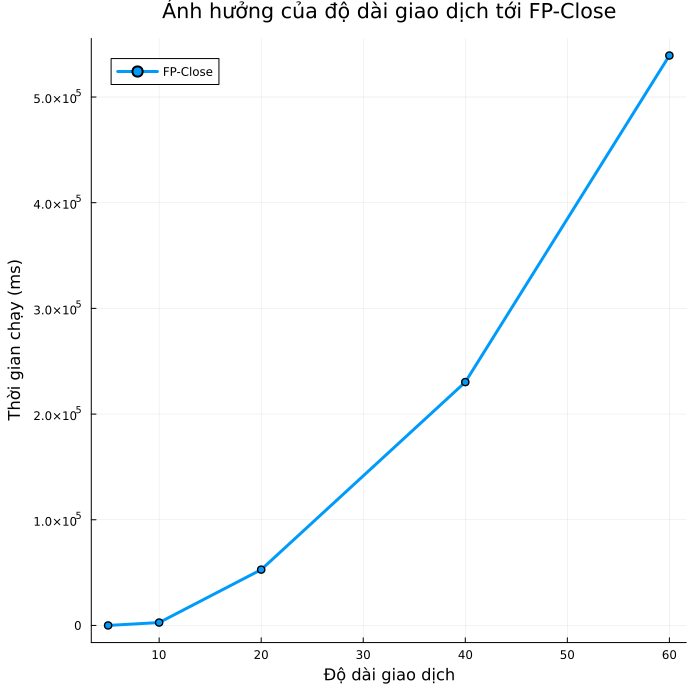

In [33]:
plot_transaction_length(df)

**Nhận xét:**

- Khi độ dài giao dịch tăng thì thời gian cũng tăng nhưng tốc độ tăng lại giảm dần theo tỷ lệ.
    - từ length = 5 đến length = 10 **tăng ~195×** (14ms → 2.742ms)

    - từ length = 10 đến length = 20 **tăng ~19×** (2.742ms → 52.812ms)

    - từ length = 20 đến length = 40 **tăng ~4.4×** (52.812ms → 230.270ms)

    - từ length = 40 đến length = 60 **tăng ~2.3×** (230.270ms → 539.257ms).

    -> Điều này phản ánh đúng cơ chế của FPClose: khi **transaction length** tăng từ 5 lên 10, số item xuất hiện tăng đột biến (từ 0 itemset lên 520 itemset), kéo theo FP-Tree đột ngột có nhiều nhánh và conditional database phải xử lý. Sau đó từ length = 20 trở đi, số itemset đã bão hòa ở 1.000 (đúng bằng N_ITEMS × minsup = 1000 × 1% = 10 itemset tối đa về lý thuyết, con số 1.000 cho thấy đã chạm trần) nên tỷ lệ tăng thời gian giảm dần.

**Điểm mạnh:**

- Xác nhận giả thuyết của nhóm
    
    - Thực nghiệm chứng minh FPClose bị ảnh hưởng bởi transaction length, đặc biệt ở giai đoạn chuyển tiếp từ "0 itemset" sang "bắt đầu có itemset frequent" (length 5 → 10). Đây là bằng chứng tốt để giải thích tại sao `Chess` và `Mushrooms` (transaction dài, dense) chậm hơn Retail.

**Điểm yếu:**

- Bước nhảy lớn tại length = 10 khi tăng 195× chỉ vì tăng độ dài thêm 5 item cho thấy thuật toán không có cơ chế "làm ấm dần" **(graceful degradation)**. Thực tế nếu ta tăng nhẹ độ dài transaction hoặc giảm nhẹ minsup, thời gian có thể tăng đột ngột không dự đoán được.

---
### Kết thúc chương 4: Thực nghiệm và Đánh giá